# Exploring Transformer Attention Mechanisms

In [1]:
# single-headed self attention

import numpy as np

In [2]:
def softmax(x):
  exp_x = np.exp(x-np.max(x, axis=-1, keepdims=True))
  return exp_x / exp_x.sum(axis=-1, keepdims=True)

In [3]:
def scaled_dot_product_attention(Q, K, V):
  d_k = Q.shape[-1] # size of q is number of neurons in layer
  #K.T is transpose of matrix K

  scores = np.matmul(Q, K.T) / np.sqrt(d_k)
  weights = softmax(scores)
  output = np.matmul(weights, V)
  return output, weights


In [9]:
#sample input(3 tokens, embedding dim =4)
Q = np.random.rand(3,4)
K = np.random.rand(3,4)
V = np.random.rand(3,4)

print("Q: \n", Q)
print("K: \n", K)
print("V: \n", V)

Q: 
 [[0.72869789 0.91985605 0.55572599 0.62223299]
 [0.45345895 0.75191377 0.52615587 0.67048137]
 [0.99562018 0.81291874 0.78024667 0.71629726]]
K: 
 [[0.89358464 0.01029531 0.12176582 0.71321195]
 [0.16200775 0.27119855 0.11226771 0.99356095]
 [0.59994419 0.93541842 0.45569747 0.15819751]]
V: 
 [[0.58792809 0.3338492  0.86949068 0.07075181]
 [0.9907154  0.17847558 0.11740069 0.66200258]
 [0.63183783 0.08095861 0.61758267 0.28919301]]


In [7]:
outputs, weights = scaled_dot_product_attention(Q, K, V)

print("Attention Output: \n", outputs)
print("Attention Weights: \n", weights) #3*3 X V -> 3*4 o/p

Attention Output: 
 [[0.56861857 0.52510374 0.29653407 0.46767177]
 [0.56808743 0.52853687 0.30234436 0.46859472]
 [0.57001952 0.49629264 0.31668659 0.49271348]]
Attention Weights: 
 [[0.30007578 0.39613939 0.30378482]
 [0.33664    0.38512881 0.2782312 ]
 [0.32746848 0.35313799 0.31939353]]


In [ ]:
# Attention Weights:
#  [[0.30007578  0.39613939 0.30378482] relation b/w i and i, i and love, i and machine
#  [0.33664    0.38512881 0.2782312 ]
#  [0.32746848 0.35313799 0.31939353]]

In [10]:
# MULTI-HEADED SELF ATTENTION

In [24]:
def multi_head_attention(Q, K, V, num_heads):
  d_model = Q.shape[1]
  d_k = d_model // num_heads

  heads_output = []

  for i in range(num_heads):
    Q_h = Q[:, i*d_k:(i+1)*d_k]
    K_h = K[:, i*d_k:(i+1)*d_k]
    V_h = V[:, i*d_k:(i+1)*d_k]

    out, _ = scaled_dot_product_attention(Q_h, K_h, V_h) #h/4
    heads_output.append(out)

  heads_output = np.concatenate(heads_output, axis=-1) #h/2
  return heads_output


In [27]:
#vary number of heads

output_2head = multi_head_attention(Q, K, V, 2)
print("Multi-Head Attention Output: \n", output_2head)

Multi-Head Attention Output: 
 [[0.70510947 0.17917661 0.51433589 0.35598894]
 [0.71490009 0.18148614 0.5120927  0.35762107]
 [0.6985008  0.18510267 0.51229379 0.35762403]]


In [28]:
output_1head = multi_head_attention(Q, K, V, 1)
print("Multi-Head Attention Output: \n", output_1head)

Multi-Head Attention Output: 
 [[0.72325772 0.18831442 0.54958919 0.33031173]
 [0.73217713 0.19034351 0.53687372 0.3398349 ]
 [0.71824403 0.19195288 0.56017826 0.3218398 ]]


In [29]:
output_4head = multi_head_attention(Q, K, V, 4)
print("Multi-Head Attention Output: \n", output_4head)

Multi-Head Attention Output: 
 [[0.7014549  0.1626502  0.54078741 0.3669625 ]
 [0.71423157 0.16896709 0.54046526 0.36911664]
 [0.68984895 0.16665868 0.54324782 0.37117318]]


### Visualization of Scaled Multi-Head Attention

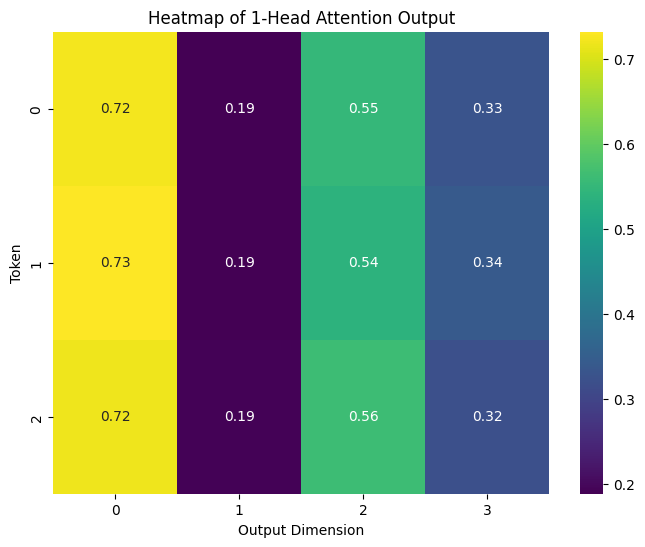

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(output_1head, annot=True, cmap='viridis', fmt=".2f")
plt.title('Heatmap of 1-Head Attention Output')
plt.xlabel('Output Dimension')
plt.ylabel('Token')
plt.show()

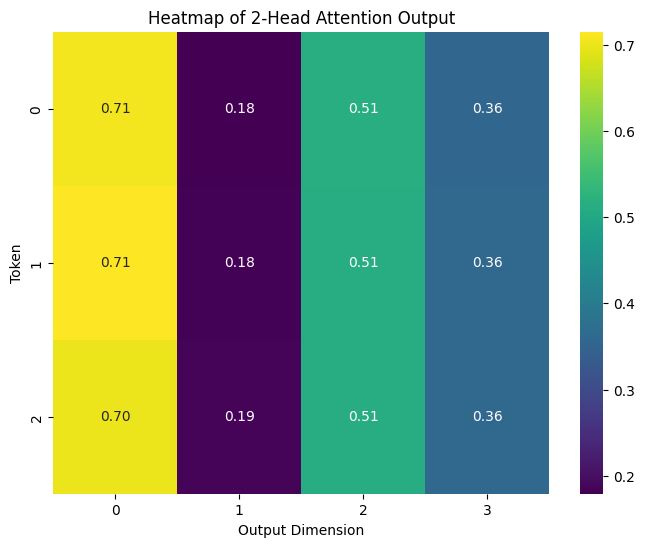

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(output_2head, annot=True, cmap='viridis', fmt=".2f")
plt.title('Heatmap of 2-Head Attention Output')
plt.xlabel('Output Dimension')
plt.ylabel('Token')
plt.show()

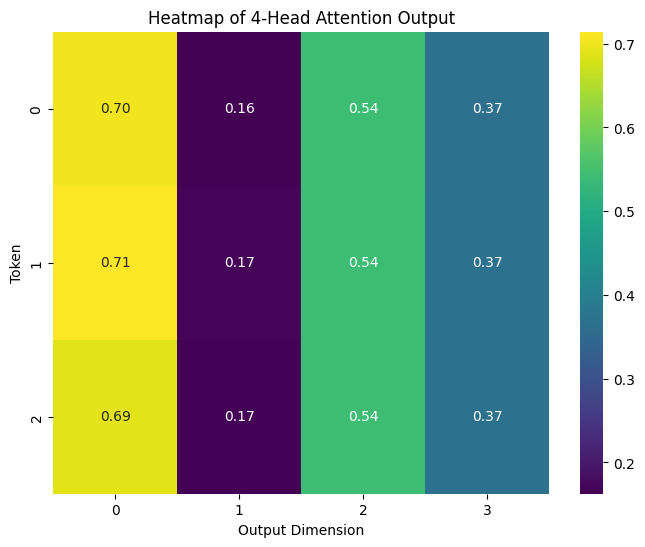

In [48]:
plt.figure(figsize=(8, 6))
sns.heatmap(output_4head, annot=True, cmap='viridis', fmt=".2f")
plt.title('Heatmap of 4-Head Attention Output')
plt.xlabel('Output Dimension')
plt.ylabel('Token')
plt.show()

## Unscaled Attention Implementations

In [41]:
def scaled_dot_product_attention_withoutscaling(Q, K, V):
  d_k = Q.shape[-1] # size of q is number of neurons in layer
  #K.T is transpose of matrix K

  scores = np.matmul(Q, K.T)
  weights = softmax(scores)
  output = np.matmul(weights, V)
  return output, weights

In [42]:
def multi_head_attention_withoutscaling(Q, K, V, num_heads):
  d_model = Q.shape[1]
  d_k = d_model // num_heads

  heads_output = []

  for i in range(num_heads):
    Q_h = Q[:, i*d_k:(i+1)*d_k]
    K_h = K[:, i*d_k:(i+1)*d_k]
    V_h = V[:, i*d_k:(i+1)*d_k]

    out, _ = scaled_dot_product_attention_withoutscaling(Q_h, K_h, V_h) #h/4
    heads_output.append(out)

  heads_output = np.concatenate(heads_output, axis=-1) #h/2
  return heads_output

### Unscaled Multi-Head Attention Outputs

In [43]:
withoutscaling_output_2head = multi_head_attention_withoutscaling(Q, K, V, 2)
print("Without scaling - Multi-Head Attention Output: \n", withoutscaling_output_2head)

Without scaling - Multi-Head Attention Output: 
 [[0.69337424 0.17049804 0.50546418 0.36265636]
 [0.70610888 0.17412992 0.5022122  0.36503271]
 [0.68536866 0.17877321 0.50252282 0.36500813]]


In [44]:
withoutscaling_output_1head = multi_head_attention_withoutscaling(Q, K, V, 1)
print("Without scaling - Multi-Head Attention Output: \n", withoutscaling_output_1head)

Without scaling - Multi-Head Attention Output: 
 [[0.70998696 0.17796477 0.56322883 0.32092677]
 [0.72706383 0.18270242 0.53949826 0.33860301]
 [0.70138603 0.18514847 0.58207261 0.30577852]]


In [45]:
withoutscaling_output_4head = multi_head_attention_withoutscaling(Q, K, V, 4)
print("Without scaling - Multi-Head Attention Output: \n", withoutscaling_output_4head)

Without scaling - Multi-Head Attention Output: 
 [[0.7014549  0.1626502  0.54078741 0.3669625 ]
 [0.71423157 0.16896709 0.54046526 0.36911664]
 [0.68984895 0.16665868 0.54324782 0.37117318]]


### Visualization of Unscaled Multi-Head Attention

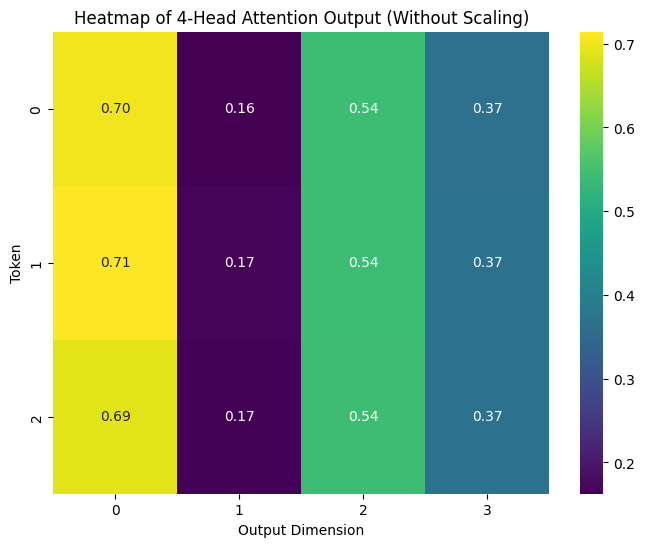

In [51]:
plt.figure(figsize=(8, 6))
sns.heatmap(withoutscaling_output_4head, annot=True, cmap='viridis', fmt=".2f")
plt.title('Heatmap of 4-Head Attention Output (Without Scaling)')
plt.xlabel('Output Dimension')
plt.ylabel('Token')
plt.show()

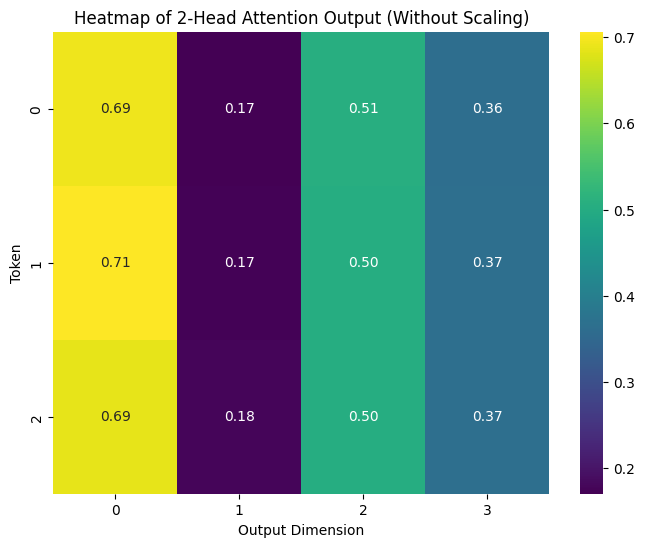

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(withoutscaling_output_2head, annot=True, cmap='viridis', fmt=".2f")
plt.title('Heatmap of 2-Head Attention Output (Without Scaling)')
plt.xlabel('Output Dimension')
plt.ylabel('Token')
plt.show()

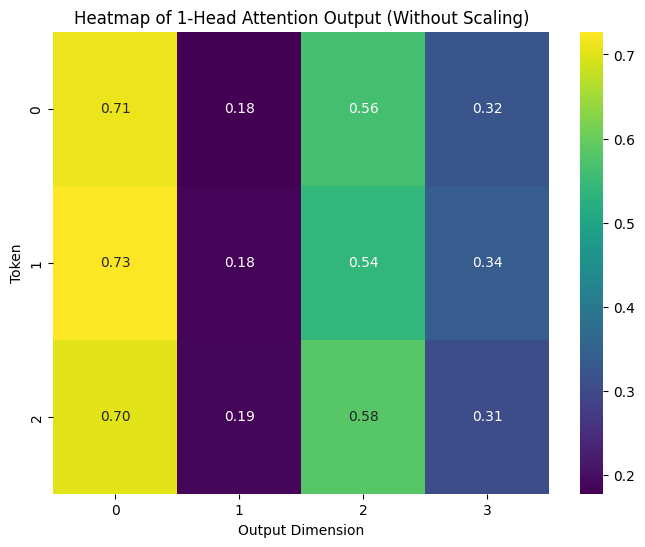

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(withoutscaling_output_1head, annot=True, cmap='viridis', fmt=".2f")
plt.title('Heatmap of 1-Head Attention Output (Without Scaling)')
plt.xlabel('Output Dimension')
plt.ylabel('Token')
plt.show()

### Comparing Scaled vs. Unscaled Multi-Head Attention Outputs

In [52]:
# Calculate absolute differences
diff_1head = np.abs(output_1head - withoutscaling_output_1head)
diff_2head = np.abs(output_2head - withoutscaling_output_2head)
diff_4head = np.abs(output_4head - withoutscaling_output_4head)

print("Absolute Difference (1-Head):\n", diff_1head)
print("Absolute Difference (2-Heads):\n", diff_2head)
print("Absolute Difference (4-Heads):\n", diff_4head)

Absolute Difference (1-Head):
 [[0.01327076 0.01034964 0.01363964 0.00938497]
 [0.00511331 0.0076411  0.00262454 0.00123188]
 [0.016858   0.0068044  0.02189435 0.01606128]]
Absolute Difference (2-Heads):
 [[0.01173522 0.00867857 0.00887171 0.00666742]
 [0.0087912  0.00735622 0.0098805  0.00741164]
 [0.01313213 0.00632946 0.00977097 0.0073841 ]]
Absolute Difference (4-Heads):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


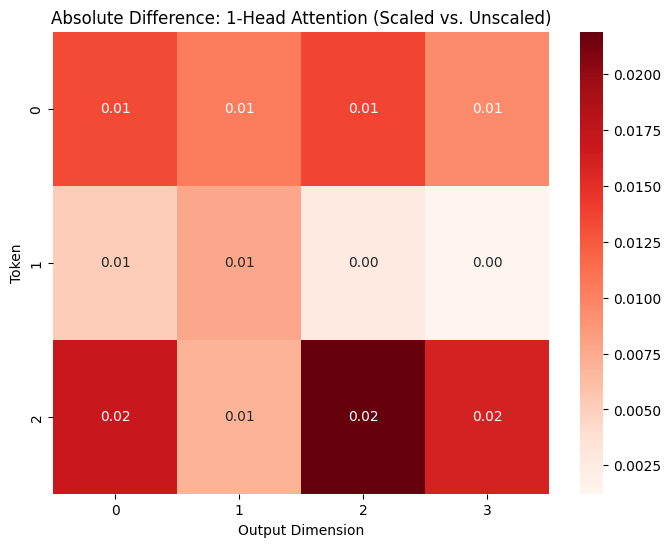

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(diff_1head, annot=True, cmap='Reds', fmt=".2f")
plt.title('Absolute Difference: 1-Head Attention (Scaled vs. Unscaled)')
plt.xlabel('Output Dimension')
plt.ylabel('Token')
plt.show()

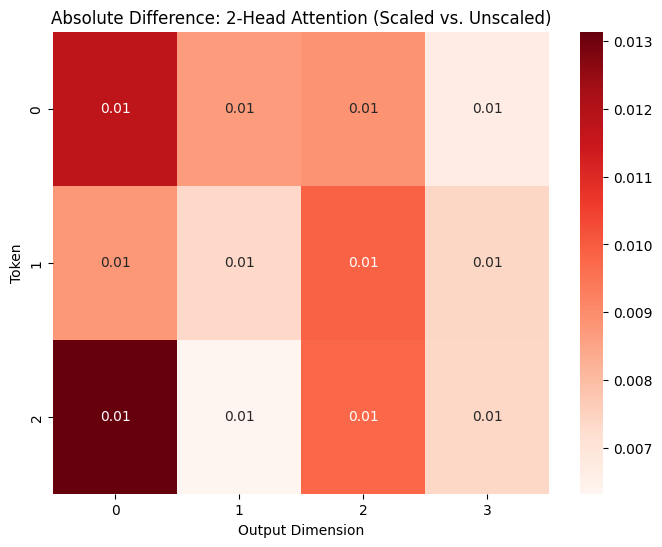

In [54]:
plt.figure(figsize=(8, 6))
sns.heatmap(diff_2head, annot=True, cmap='Reds', fmt=".2f")
plt.title('Absolute Difference: 2-Head Attention (Scaled vs. Unscaled)')
plt.xlabel('Output Dimension')
plt.ylabel('Token')
plt.show()

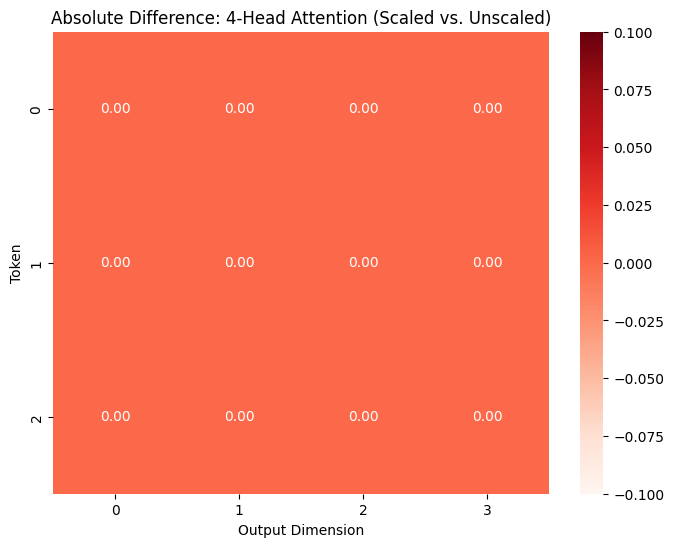

In [55]:
plt.figure(figsize=(8, 6))
sns.heatmap(diff_4head, annot=True, cmap='Reds', fmt=".2f")
plt.title('Absolute Difference: 4-Head Attention (Scaled vs. Unscaled)')
plt.xlabel('Output Dimension')
plt.ylabel('Token')
plt.show()

**Conclusion:**
While the heatmaps for 1-head and 2-head attention did show some differences, they were numerically quite small. Here's why this might be the case and why scaling is still important:

*   **Small Input Values:** Our `Q`, `K`, and `V` matrices are generated using `np.random.rand(3,4)`, which produces random numbers between 0 and 1. When these values are multiplied (dot product) in the scores calculation, the resulting numbers are often not extremely large or extremely small. The effect of dividing by `sqrt(d_k)` (which is `sqrt(4) = 2` for 1-head, and `sqrt(2) = 1.414` for 2-head) might not drastically change the relative magnitudes of the scores enough to cause huge shifts in the softmax output, especially if the original scores aren't widely spread.

*   **Softmax Properties**: The softmax function is designed to convert any real-valued vector into a probability distribution. If the input scores are already relatively well-behaved, the softmax might produce similar distributions even with slight variations in its input. Scaling helps to keep the dot products in a range where the softmax gradient doesn't vanish, which is more critical in deeper networks with many layers and larger embedding dimensions.

*   **The 4-Head Exception:** For the 4-head case, `d_k` became 1 (since `d_model // num_heads = 4 // 4 = 1`). Dividing by `sqrt(1)` (which is 1) has no effect, so the scaled and unscaled versions are mathematically identical, resulting in zero difference.

*   **Deep Learning Context (Why Scaling Matters More in Practice):** In real-world deep learning models, especially with larger embedding dimensions (`d_model`) and longer sequences, the dot products can become very large. Without scaling, these large values can push the softmax function into regions where its gradients are extremely small (saturating the softmax), making it difficult for the model to learn effectively during training. The scaling factor helps to normalize these scores, keeping them in a more stable range for the softmax and preventing gradient vanishing issues over many layers.

Therefore, while the visual differences in this small example might not be dramatic, the scaling factor is a crucial stabilization technique in larger transformer architectures to ensure effective training.

### Comparing Softmax Output Distributions (Scaled vs. Unscaled)

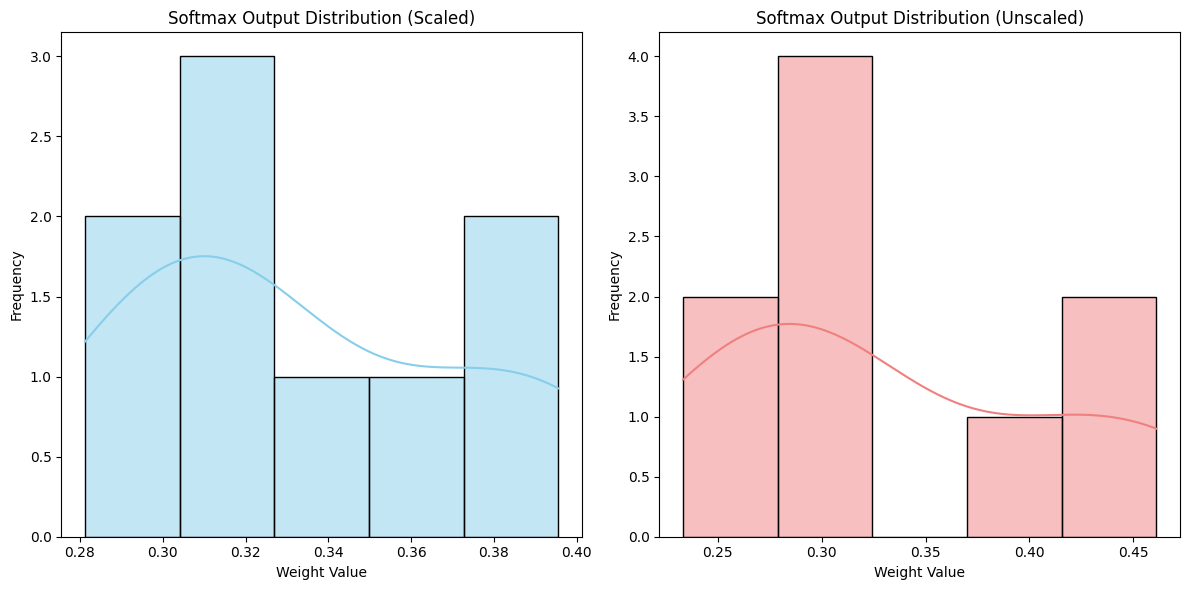

In [56]:
# Recalculate weights from scaled_dot_product_attention to ensure we have the most recent `weights` variable
_, scaled_weights = scaled_dot_product_attention(Q, K, V)

# Calculate weights from scaled_dot_product_attention_withoutscaling
_, unscaled_weights = scaled_dot_product_attention_withoutscaling(Q, K, V)

# Flatten the weight arrays for histogram plotting
scaled_weights_flat = scaled_weights.flatten()
unscaled_weights_flat = unscaled_weights.flatten()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(scaled_weights_flat, kde=True, color='skyblue')
plt.title('Softmax Output Distribution (Scaled)')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(unscaled_weights_flat, kde=True, color='lightcoral')
plt.title('Softmax Output Distribution (Unscaled)')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Analysis of Softmax Output Distributions (Scaled vs. Unscaled)

The histograms above visualize the distribution of attention weights after applying the softmax function, both with and without the `sqrt(d_k)` scaling factor.

**Scaled Softmax Distribution (Left Histogram):**
*   This histogram typically shows a more spread-out distribution of weights. The `sqrt(d_k)` scaling factor, by reducing the magnitude of the scores before softmax, often leads to a less 'peaky' distribution, allowing more tokens to have non-negligible attention weights. This can be beneficial for the model to attend to a wider range of context.

**Unscaled Softmax Distribution (Right Histogram):**
*   Without the scaling factor, the dot products can become larger. When these larger scores are fed into the softmax function, it tends to make the distribution sharper, assigning a very high probability to one or a few tokens and very low probabilities to others. This is due to the exponential nature of softmax, which amplifies differences in input values.

**Implications:**
*   **Gradient Stability:** In deep learning, a very sharp softmax distribution (common with unscaled scores) can lead to 'vanishing gradients' during training. When one weight becomes dominant, its gradient might be very small, making it difficult for the model to learn from other, less dominant attention weights.
*   **Information Flow:** A more diverse distribution of attention weights (as seen with scaling) allows more information to flow from different parts of the input sequence, which is generally desired in complex tasks. A sharp distribution might cause the model to 'focus' too heavily on a few elements, potentially missing important contextual cues.

Although the visual differences in this small example might seem subtle, in larger models with higher dimensional embeddings, the scaling factor plays a critical role in stabilizing training and enabling more effective learning by preventing the softmax from becoming too 'hard' or saturated.